In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers

In [2]:
df = pd.read_csv('../data/TMNIST_Data.csv')
print(df.head(2))

                        names  labels  1  2  3  4  5  6  7  8  ...  775  776  \
0          GrandHotel-Regular       2  0  0  0  0  0  0  0  0  ...    0    0   
1  EncodeSansCondensed-Medium       8  0  0  0  0  0  0  0  0  ...    0    0   

   777  778  779  780  781  782  783  784  
0    0    0    0    0    0    0    0    0  
1    0    0    0    0    0    0    0    0  

[2 rows x 786 columns]


In [3]:
# Get the raw pixel values
raw_pixels = df.drop(columns=['names', 'labels']).values

print("Raw max pixel value:", raw_pixels.max())
print("Raw min pixel value:", raw_pixels.min())

Raw max pixel value: 255
Raw min pixel value: 0


In [4]:
labels = df['labels'].values
images = df.drop(columns=['names', 'labels']).values

# Reshape the size of all images into 28x28
images = images.reshape(-1, 28, 28, 1)

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2)

In [5]:
# Normalize the pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

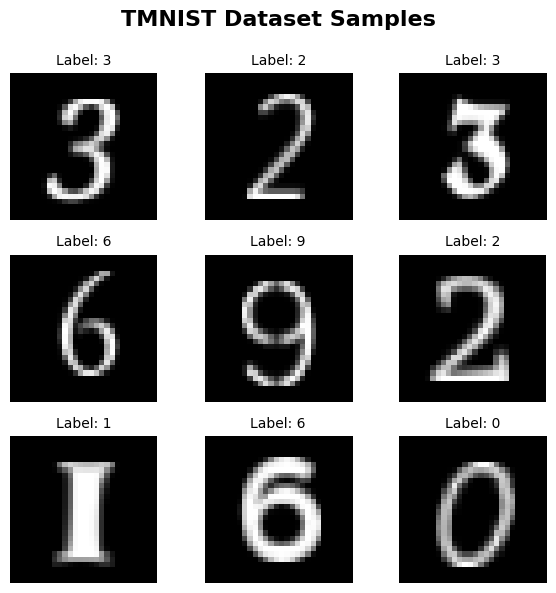

In [6]:
random_indices = np.random.choice(len(images), size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(6, 6))

plt.suptitle("TMNIST Dataset Samples", fontsize=16, fontweight='bold', y=0.98)

for i, ax in enumerate(axes.flat):
    # Get the index of the image
    idx = random_indices[i]

    # Reshape the image
    img = images[idx].reshape(28, 28)

    # Show the image
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[idx]}", fontsize=10)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.99])  # leave the top 1% to be blank for the super title
plt.show()

In [7]:
# Normalize the pixel values
# x_train, x_test = x_train / 255.0, x_test / 255.0

In [8]:
# Reshape the dataset
# (# of images, height, width, # of colour channels)
# NOTE: -1 tells Python to figure out the number of images automatically
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [9]:
# Create a model
model = tf.keras.Sequential([

    # First layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Dense layer for classification (10 outputs in total)
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# Summary of the model
model.summary()

/Users/neil/Develop/SudoVisionCruncher/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-17 11:58:25.895977: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-17 11:58:25.896020: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-17 11:58:25.896027: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1779037105.896049  465299 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779037105.896086  465299 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/tas

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Create a callback to stop training when the improvement metric has stopped improving
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # set the improvement metric to value loss
    patience=3, # the number of epochs to wait
    restore_best_weights=True   # roll back the model to its best performance state
)

In [12]:
# Train the model
history = model.fit(x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback])

Epoch 1/20


2026-05-17 11:58:26.222183: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8853 - loss: 0.3627 - val_accuracy: 0.9758 - val_loss: 0.0946
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9760 - loss: 0.0889 - val_accuracy: 0.9820 - val_loss: 0.0652
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9810 - loss: 0.0727 - val_accuracy: 0.9833 - val_loss: 0.0609
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9836 - loss: 0.0624 - val_accuracy: 0.9858 - val_loss: 0.0566
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9846 - loss: 0.0592 - val_accuracy: 0.9900 - val_loss: 0.0503
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9869 - loss: 0.0552 - val_accuracy: 0.9908 - val_loss: 0.0442
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9879 - loss: 0.0500 - val_accuracy: 0.9916 - val_loss: 0.0442
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9893 - loss: 0.0510 - val_accuracy: 0.9908 - val_

In [13]:
print(f"Number of epoch are run: {len(history.history['loss'])}")

Number of epoch are run: 9


In [14]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

187/187 - 1s - 4ms/step - accuracy: 0.9875 - loss: 0.0608

Test Accuracy: 98.75%


In [15]:
# Save the model and its parameters
model.save('../models/digit_recognition_model_TMNIST.keras')